In [1]:
#============================================================
## 1. IMPORT LIBRARIES
#============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#============================================================
## 2. LOAD DATASET
#============================================================

df = pd.read_csv("/content/sample_data/diabetes_prediction_dataset.csv")

In [3]:
#===========================================================
## 3. EXPLORATORY DATA ANALYSIS (EDA)
#============================================================
# Basic Info

print("Shape:", df.shape)
print("\nData Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Missing Values

print("\nMissing Values:\n", df.isnull().sum())

# Duplicate Values

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (100000, 9)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Summary Statistics:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std    

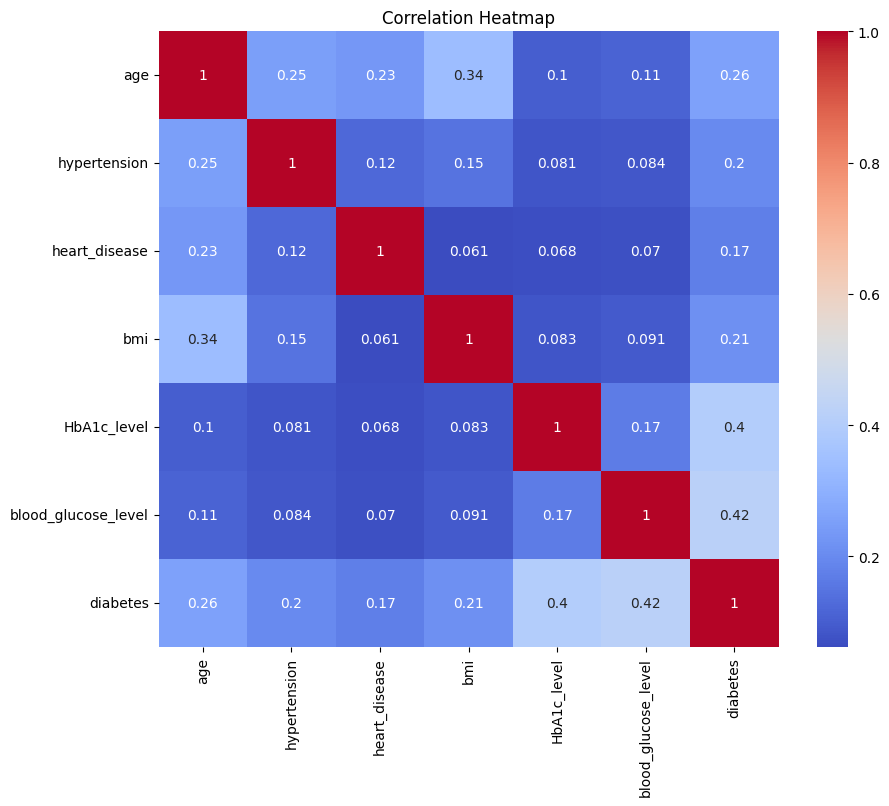

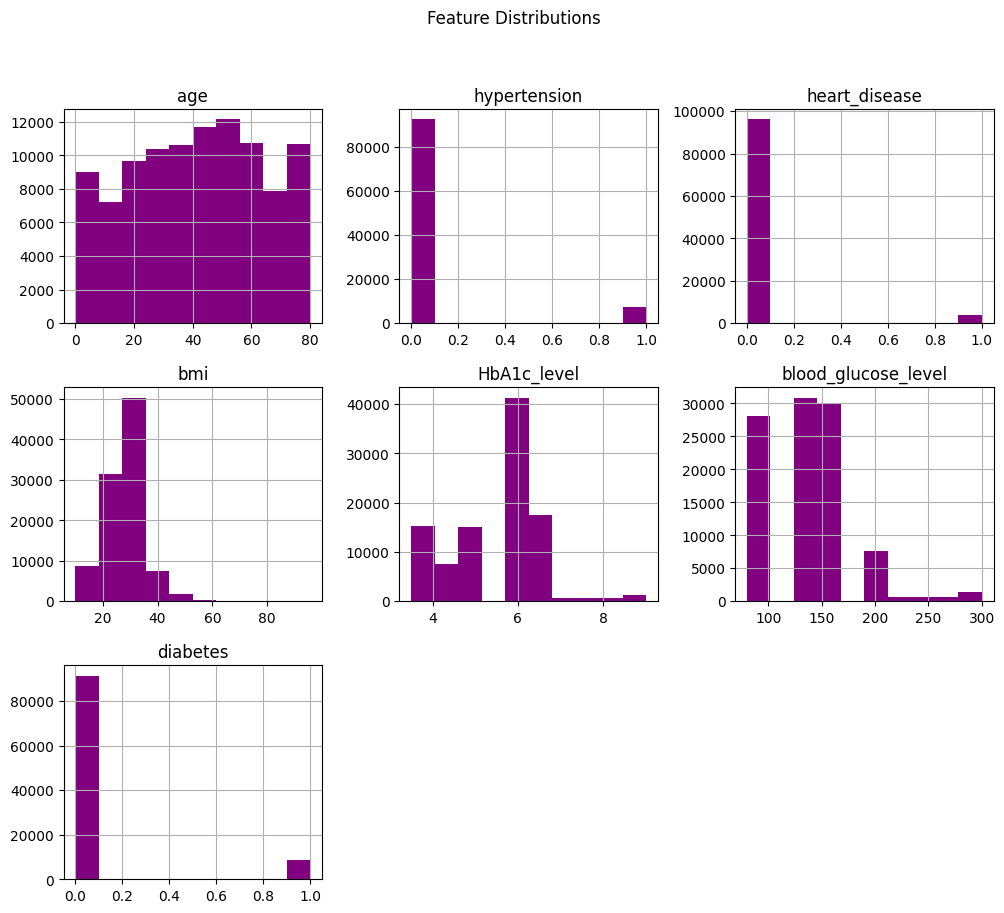

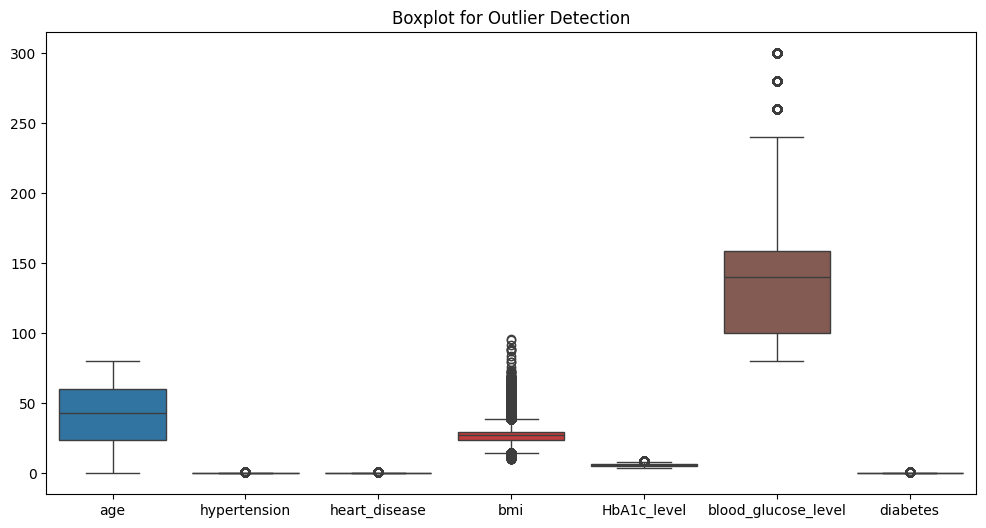

In [6]:
import numpy as np
#============================================================
## 4. VISUALIZATION
#============================================================
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Histograms

df.hist(figsize=(12,10),color='purple')
plt.suptitle("Feature Distributions")
plt.show()

# Boxplots (Outliers)

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [30]:
#============================================================
## 5. DATA PREPROCESSING
#============================================================
# Split features & target

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True)

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
#============================================================
## 6. MODEL 1 - LOGISTIC REGRESSION
#============================================================

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("F1 Score:", f1_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

===== Logistic Regression =====
Accuracy: 0.95905
F1 Score: 0.7201913221728733
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.86      0.62      0.72      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [32]:
#============================================================
## 7. MODEL 2 - KNN
#============================================================

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_preds = knn_model.predict(X_test_scaled)

print("===== KNN =====")
print("Accuracy:", accuracy_score(y_test, knn_preds))
print("F1 Score:", f1_score(y_test, knn_preds))
print(classification_report(y_test, knn_preds))

===== KNN =====
Accuracy: 0.96055
F1 Score: 0.7255652173913043
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.89      0.61      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.93      0.80      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [33]:
#============================================================
## 8. MODEL 3 - RANDOM FOREST
#============================================================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("F1 Score:", f1_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

===== Random Forest =====
Accuracy: 0.9699
F1 Score: 0.7957937584803256
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



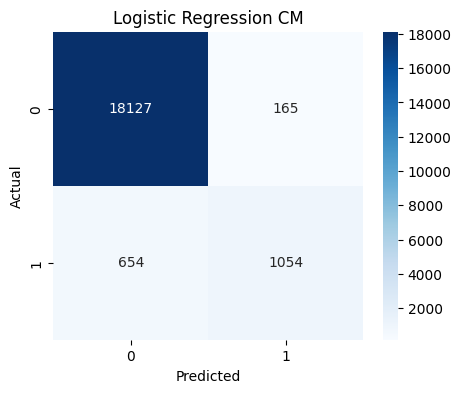

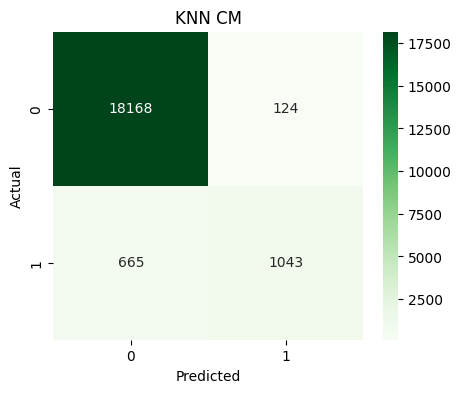

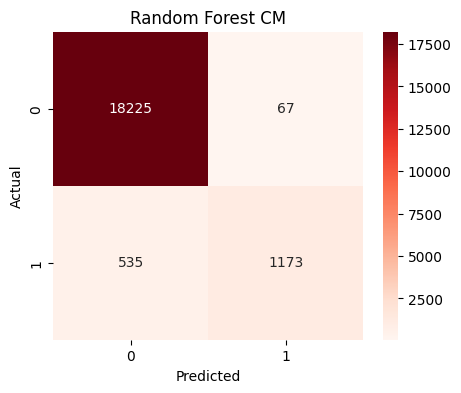

In [34]:
#============================================================
## 9. CONFUSION MATRIX VISUALIZATION
#============================================================

def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap= cmap)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, lr_preds, "Logistic Regression CM", "Blues")
plot_confusion_matrix(y_test, knn_preds, "KNN CM","Greens")
plot_confusion_matrix(y_test, rf_preds, "Random Forest CM","Reds")

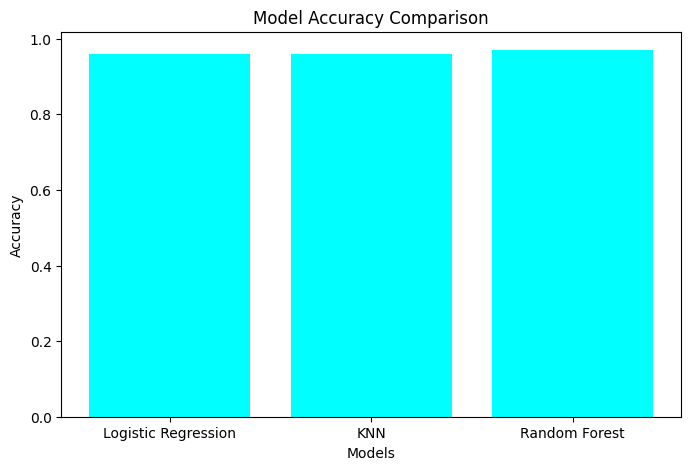

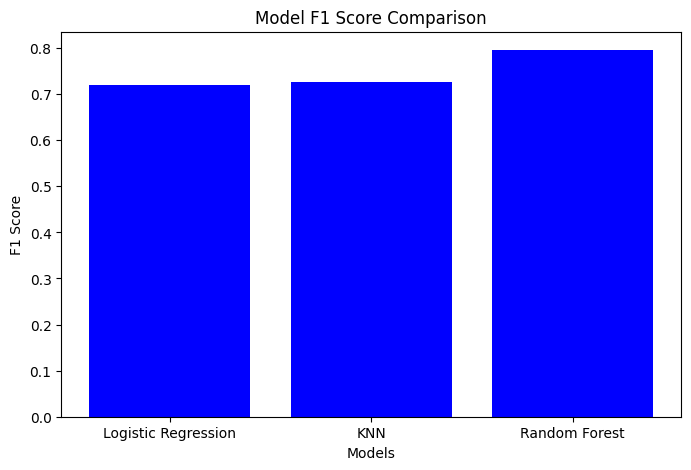

In [35]:
#============================================================
## 10. MODEL COMPARISON
#============================================================

# Results DataFrame
results = pd.DataFrame({
"Model": ["Logistic Regression", "KNN", "Random Forest"],
"Accuracy": [
accuracy_score(y_test, lr_preds),
accuracy_score(y_test, knn_preds),
accuracy_score(y_test, rf_preds)
],
"F1 Score": [
f1_score(y_test, lr_preds),
f1_score(y_test, knn_preds),
f1_score(y_test, rf_preds)
]
})

# Plot Accuracy Comparison

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"],color='cyan')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

# Plot F1 Score Comparison

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["F1 Score"],color='blue')
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.show()

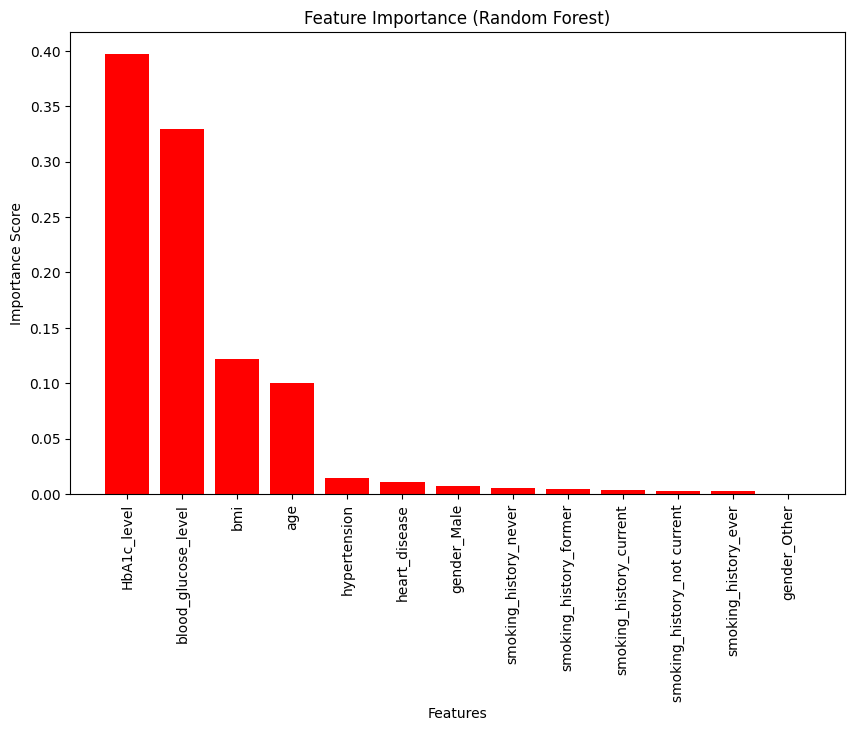

In [28]:
#============================================================
## 12. FEATURE IMPORTANCE (RANDOM FOREST)
#============================================================
# Get feature importance

importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame

feat_df = pd.DataFrame({
"Feature": feature_names,
"Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot

plt.figure(figsize=(10,6))
plt.bar(feat_df["Feature"], feat_df["Importance"],color='red')
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()


In [18]:
#============================================================
## 11. INTERPRETATION (IMPORTANT FOR REPORT)
#============================================================

print("\nINTERPRETATION:")
print("""

Logistic Regression provides a baseline model with good interpretability.

KNN performance depends on the choice of k and data scaling.

Random Forest usually performs better due to ensemble learning.

The best model is selected based on highest Accuracy and F1 Score.

F1 Score is important because it balances precision and recall.

Features like Glucose, BMI, and Age tend to have strong influence on predicting diabetes.

This model can help in early detection of diabetes risk, which is valuable in real-world healthcare applications.
""")


INTERPRETATION:


Logistic Regression provides a baseline model with good interpretability.

KNN performance depends on the choice of k and data scaling.

Random Forest usually performs better due to ensemble learning.

The best model is selected based on highest Accuracy and F1 Score.

F1 Score is important because it balances precision and recall.

Features like Glucose, BMI, and Age tend to have strong influence on predicting diabetes.

This model can help in early detection of diabetes risk, which is valuable in real-world healthcare applications.

